Normalized 5x5 DoG kernel in x-direction:
[[ 0.04413011  0.06420893  0.07275825  0.06420893  0.04413011]
 [ 0.03210446  0.04671172  0.05293131  0.04671172  0.03210446]
 [ 0.          0.          0.          0.          0.        ]
 [-0.03210446 -0.04671172 -0.05293131 -0.04671172 -0.03210446]
 [-0.04413011 -0.06420893 -0.07275825 -0.06420893 -0.04413011]]

Normalized 5x5 DoG kernel in y-direction:
[[ 0.04413011  0.03210446  0.         -0.03210446 -0.04413011]
 [ 0.06420893  0.04671172  0.         -0.04671172 -0.06420893]
 [ 0.07275825  0.05293131  0.         -0.05293131 -0.07275825]
 [ 0.06420893  0.04671172  0.         -0.04671172 -0.06420893]
 [ 0.04413011  0.03210446  0.         -0.03210446 -0.04413011]]


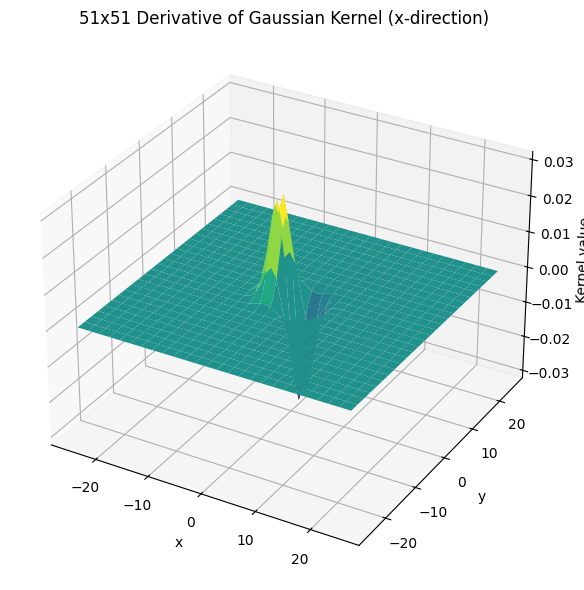

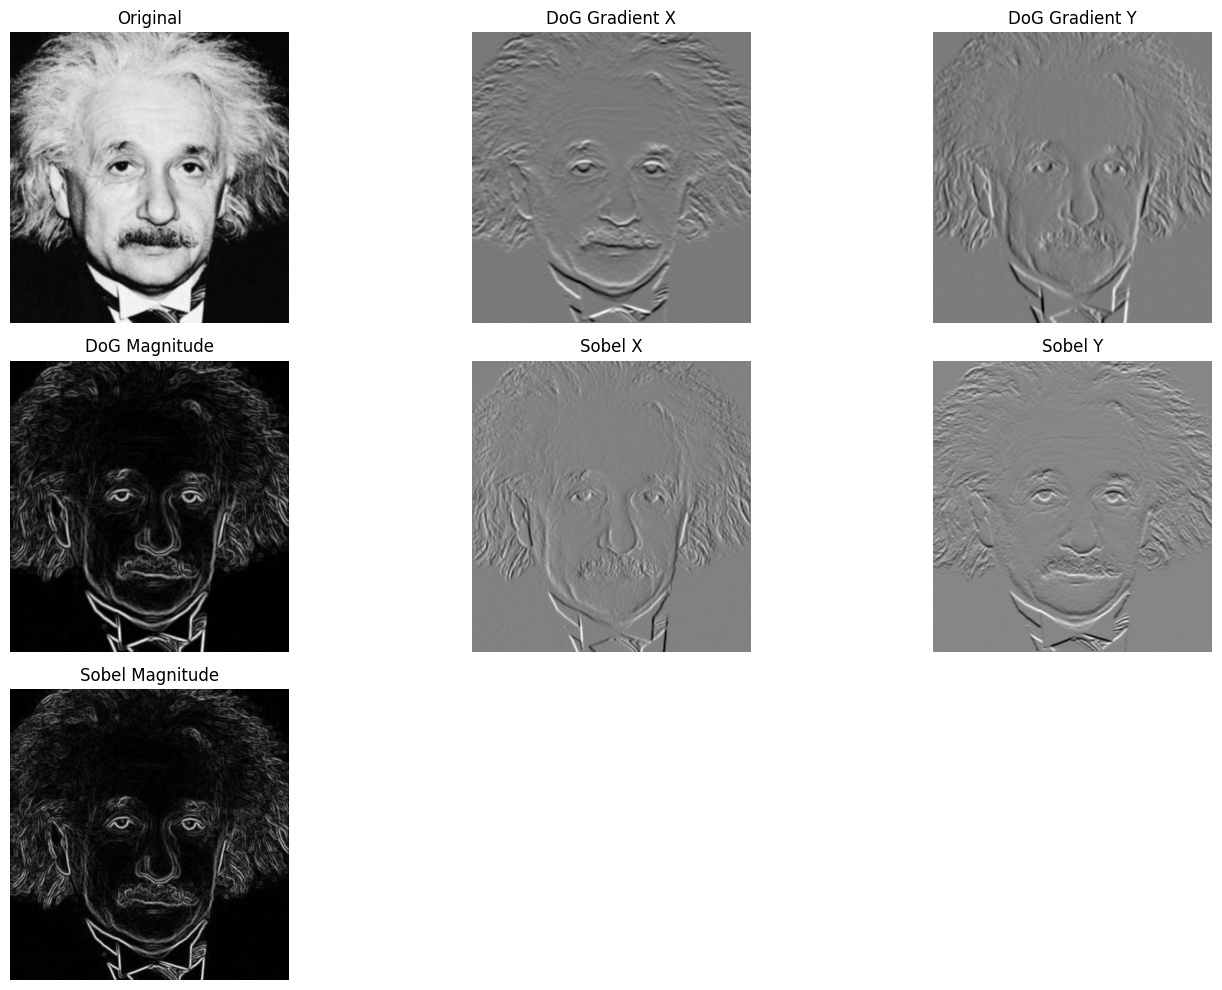

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

#Derivative of Gaussian

#2D Gaussian function
def gaussian(x, y, sigma):
    return (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))


#Derivative of Gaussian kernels
def dog_kernels(size, sigma):
    if size % 2 == 0:
        raise ValueError("Kernel size must be odd")

    k = size // 2
    x, y = np.mgrid[-k:k+1, -k:k+1]

    G = gaussian(x, y, sigma)
    Gx = (-x / sigma**2) * G
    Gy = (-y / sigma**2) * G

    #Normalize using sum of absolute values
    Gx = Gx / np.sum(np.abs(Gx))
    Gy = Gy / np.sum(np.abs(Gy))

    return Gx, Gy


#Display signed gradients as gray images
#negative -> dark, zero -> gray, positive -> bright
def signed_display(img):
    m = np.max(np.abs(img))
    if m == 0:
        return np.full(img.shape, 128, dtype=np.uint8)
    out = (img / m) * 127 + 128
    return np.clip(out, 0, 255).astype(np.uint8)

#Display magnitude images
def magnitude_display(img):
    return cv.normalize(img, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

#Compute normalized 5x5 kernels
sigma = 2
Gx, Gy = dog_kernels(5, sigma)

print("Normalized 5x5 DoG kernel in x-direction:")
print(Gx)

print("\nNormalized 5x5 DoG kernel in y-direction:")
print(Gy)

#Visualize 51x51 DoG kernel
size_large = 51
k_large = size_large // 2
x_large, y_large = np.mgrid[-k_large:k_large+1, -k_large:k_large+1]

G_large = gaussian(x_large, y_large, sigma)
Gx_large = (-x_large / sigma**2) * G_large
Gx_large = Gx_large / np.sum(np.abs(Gx_large))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x_large, y_large, Gx_large, cmap='viridis')
ax.set_title("51x51 Derivative of Gaussian Kernel (x-direction)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Kernel value")
plt.tight_layout()
plt.show()

# Save 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x_large, y_large, Gx_large, cmap='viridis')
ax.set_title("51x51 Derivative of Gaussian Kernel (x-direction)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Kernel value")
plt.tight_layout()
plt.savefig("q6_dog_kernel_3d.png")
plt.close()

#Load grayscale image
img = cv.imread("/content/input_einstein.png", cv.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Could not load image. Check the file path.")

#Compute normalized 5x5 kernels
sigma = 2
Gx, Gy = dog_kernels(5, sigma)

#Apply DoG kernels to image
grad_x = cv.filter2D(img.astype(np.float64), cv.CV_64F, Gx)
grad_y = cv.filter2D(img.astype(np.float64), cv.CV_64F, Gy)

#Gradient magnitude
mag_dog = np.sqrt(grad_x**2 + grad_y**2)

#Apply Sobel and compare
sobel_x = cv.Sobel(img, cv.CV_64F, 1, 0, ksize=3)
sobel_y = cv.Sobel(img, cv.CV_64F, 0, 1, ksize=3)

#Sobel magnitude
mag_sobel = np.sqrt(sobel_x**2 + sobel_y**2)

#Convert results for display
grad_x_disp = signed_display(grad_x)
grad_y_disp = signed_display(grad_y)

sobel_x_disp = signed_display(sobel_x)
sobel_y_disp = signed_display(sobel_y)

mag_dog_disp = magnitude_display(mag_dog)
mag_sobel_disp = magnitude_display(mag_sobel)

# Display results
plt.figure(figsize=(14, 10))

plt.subplot(3, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(3, 3, 2)
plt.imshow(grad_x_disp, cmap='gray')
plt.title("DoG Gradient X")
plt.axis("off")

plt.subplot(3, 3, 3)
plt.imshow(grad_y_disp, cmap='gray')
plt.title("DoG Gradient Y")
plt.axis("off")

plt.subplot(3, 3, 4)
plt.imshow(mag_dog_disp, cmap='gray')
plt.title("DoG Magnitude")
plt.axis("off")

plt.subplot(3, 3, 5)
plt.imshow(sobel_x_disp, cmap='gray')
plt.title("Sobel X")
plt.axis("off")

plt.subplot(3, 3, 6)
plt.imshow(sobel_y_disp, cmap='gray')
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(3, 3, 7)
plt.imshow(mag_sobel_disp, cmap='gray')
plt.title("Sobel Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()

# Save output images
cv.imwrite("q6_dog_grad_x.png", grad_x_disp)
cv.imwrite("q6_dog_grad_y.png", grad_y_disp)
cv.imwrite("q6_dog_magnitude.png", mag_dog_disp)

cv.imwrite("q6_sobel_x.png", sobel_x_disp)
cv.imwrite("q6_sobel_y.png", sobel_y_disp)
cv.imwrite("q6_sobel_magnitude.png", mag_sobel_disp)

# Save combined comparison figure
plt.figure(figsize=(14, 10))

plt.subplot(3, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(3, 3, 2)
plt.imshow(grad_x_disp, cmap='gray')
plt.title("DoG Gradient X")
plt.axis("off")

plt.subplot(3, 3, 3)
plt.imshow(grad_y_disp, cmap='gray')
plt.title("DoG Gradient Y")
plt.axis("off")

plt.subplot(3, 3, 4)
plt.imshow(mag_dog_disp, cmap='gray')
plt.title("DoG Magnitude")
plt.axis("off")

plt.subplot(3, 3, 5)
plt.imshow(sobel_x_disp, cmap='gray')
plt.title("Sobel X")
plt.axis("off")

plt.subplot(3, 3, 6)
plt.imshow(sobel_y_disp, cmap='gray')
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(3, 3, 7)
plt.imshow(mag_sobel_disp, cmap='gray')
plt.title("Sobel Magnitude")
plt.axis("off")

plt.tight_layout()
plt.savefig("q6_dog_vs_sobel.png")
plt.close()